# Imports

In [42]:
!pip install pandas


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [43]:
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np

# Load dataset

In [44]:
df1 = pd.read_csv("twitter_training.csv",header=None)
df2 = pd.read_csv("twitter_validation.csv",header=None)
df1.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [45]:
df2.head()

,0,1,2,3
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [46]:
df1.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
74677    False
74678    False
74679    False
74680    False
74681    False
Length: 74682, dtype: bool

In [47]:
df1.drop_duplicates([3], keep='last')

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...


In [48]:
df1.isna().sum()

0      0
1      0
2      0
3    686
dtype: int64

In [49]:
df2.isna().sum()

0    0
1    0
2    0
3    0
dtype: int64

In [50]:
df1[df1.isnull().any(axis=1)]

,0,1,2,3
61,2411,Borderlands,Neutral,NaN
553,2496,Borderlands,Neutral,NaN
589,2503,Borderlands,Neutral,NaN
745,2532,Borderlands,Positive,NaN
1105,2595,Borderlands,Positive,NaN
...,...,...,...,...
73972,9073,Nvidia,Positive,NaN
73973,9073,Nvidia,Positive,NaN
74421,9154,Nvidia,Positive,NaN
74422,9154,Nvidia,Positive,NaN


In [51]:
df1.count()

0    74682
1    74682
2    74682
3    73996
dtype: int64

In [52]:
df1.dropna(subset = [3], inplace=True)


In [53]:
df1.isna().sum()

0    0
1    0
2    0
3    0
dtype: int64

In [54]:
def fit_label_encoder(labels):
    """
    Tokenizes the labels
    
    Args:
        labels (list[str]): labels to tokenize
    
    Returns:
        tf.keras.layers.StringLookup: adapted encoder for labels
    """
    ### START CODE HERE ###
    
    # Instantiate the StringLookup layer. Remember that you don't want any OOV tokens!
    label_encoder = tf.keras.layers.StringLookup(num_oov_indices=0)
    
    # Adapt the StringLookup layer to the labels
    label_encoder.adapt(labels)
	
    ### END CODE HERE ###
    
    return label_encoder

In [55]:
# Create the encoder adapted to the labels
label_encoder = fit_label_encoder(df1[2].tolist())

# Get the vocabulary
vocabulary = label_encoder.get_vocabulary()

# Encode labels
label_sequences1 = label_encoder(df1[2].tolist())

print(f"Vocabulary of labels looks like this: {vocabulary}\n")
print(f"First 13 labels: {df1[2].tolist()[:13]}\n")
print(f"First 13 label sequences: {label_sequences1[:13]}\n")

Vocabulary of labels looks like this: [np.str_('Negative'), np.str_('Positive'), np.str_('Neutral'), np.str_('Irrelevant')]

First 13 labels: ['Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Neutral']

First 13 label sequences: [1 1 1 1 1 1 1 1 1 1 1 1 2]



In [56]:
# Create the encoder adapted to the labels
label_encoder2 = fit_label_encoder(df2[2].to_numpy())

# Get the vocabulary
vocabulary2 = label_encoder2.get_vocabulary()

# Encode labels
label_sequences2 = label_encoder(df2[2].to_numpy())

print(f"Vocabulary of labels looks like this: {vocabulary2}\n")
print(f"First 13 labels: {df2[2].tolist()[:13]}\n")
print(f"First 13 label sequences: {label_sequences2[:13]}\n")

Vocabulary of labels looks like this: [np.str_('Neutral'), np.str_('Positive'), np.str_('Negative'), np.str_('Irrelevant')]

First 13 labels: ['Irrelevant', 'Neutral', 'Negative', 'Negative', 'Neutral', 'Negative', 'Positive', 'Positive', 'Positive', 'Negative', 'Positive', 'Positive', 'Negative']

First 13 label sequences: [3 2 0 0 2 0 1 1 1 0 1 1 0]



In [57]:
label_sequences2

<tf.Tensor: shape=(1000,), dtype=int64, numpy=
array([3, 2, 0, 0, 2, 0, 1, 1, 1, 0, 1, 1, 0, 2, 0, 1, 1, 0, 1, 0, 0, 2,
       3, 0, 2, 2, 0, 3, 3, 0, 1, 1, 0, 1, 0, 2, 2, 3, 1, 2, 1, 2, 2, 2,
       1, 2, 0, 0, 0, 2, 1, 0, 0, 1, 1, 1, 1, 1, 0, 3, 0, 1, 1, 3, 0, 2,
       0, 3, 2, 0, 1, 0, 0, 1, 1, 3, 1, 3, 2, 2, 2, 1, 1, 2, 1, 2, 0, 3,
       0, 2, 2, 0, 1, 3, 3, 0, 0, 0, 2, 1, 2, 0, 1, 1, 2, 1, 2, 1, 0, 2,
       2, 2, 0, 2, 0, 2, 2, 1, 1, 2, 0, 0, 1, 0, 2, 0, 1, 2, 0, 2, 3, 1,
       2, 1, 1, 3, 2, 2, 3, 3, 3, 2, 2, 3, 3, 3, 1, 2, 1, 3, 1, 0, 2, 2,
       2, 3, 2, 0, 2, 1, 0, 2, 0, 3, 3, 3, 2, 0, 0, 0, 1, 1, 1, 2, 2, 1,
       3, 2, 2, 2, 1, 2, 0, 0, 2, 1, 1, 3, 3, 2, 1, 1, 2, 3, 2, 0, 0, 0,
       0, 1, 2, 2, 1, 1, 1, 1, 0, 1, 1, 3, 2, 3, 0, 0, 3, 3, 0, 1, 1, 0,
       3, 0, 1, 1, 0, 3, 3, 1, 1, 0, 1, 3, 2, 3, 3, 0, 2, 2, 1, 0, 3, 3,
       1, 1, 3, 3, 2, 1, 0, 0, 1, 1, 1, 1, 2, 2, 1, 0, 2, 1, 2, 0, 2, 2,
       0, 1, 1, 3, 0, 2, 3, 1, 2, 3, 0, 2, 0, 1, 1, 0, 0, 0, 1, 0, 2, 1,
    

In [58]:
#df1[2]=df1[2].map({"Positive":1,"Negative":0,"Neutral":2,"Irrelevant":3})
#delneutral1.head(13)

In [59]:
#df2[2]=df2[2].map({"Positive":1,"Negative":0,"Neutral":2,"Irrelevant":3})
#delneutral2.head(12)

In [60]:
#df1[delneutral1!= 2]
#df2[delneutral2!= 2]

In [61]:
df1.head(12)

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...


In [62]:
#description
reviews1 = df1[3].to_numpy()
#rating
ratings1 = label_sequences1

In [63]:
reviews2 = df2[3].to_numpy()
ratings2 = label_sequences2

# Parameters

In [64]:
EMBEDDING_DIM = 100
MAX_LENGTH = 32
TRAINING_SPLIT = 1000
NUM_BATCHES = 128
# Type of padding
PADDING_TYPE = 'pre'

# Specifies how to truncate the sequences
TRUNC_TYPE = 'post'

# Split

In [65]:
train_sentences = reviews1
test_sentences = reviews2
# Split the labels
train_labels = ratings1
test_labels = ratings2

In [66]:
len(test_sentences)

1000

In [67]:
#initialize the layer
vectorize_layer = tf.keras.layers.TextVectorization( 
        standardize="lower_and_strip_punctuation",
        output_sequence_length=MAX_LENGTH
    ) 
#compute the vocabulary
vectorize_layer.adapt(train_sentences)
# Get the vocabulary
vocabulary = vectorize_layer.get_vocabulary()

In [68]:
# Check size of vocabulary
vocab_size = vectorize_layer.vocabulary_size()

print(f"Vocabulary contains {vocab_size} words\n")

Vocabulary contains 42559 words



In [69]:
# Apply the layer to the string input list. post padded
train_vectorized = vectorize_layer(train_sentences)

In [70]:
test_vectorized = vectorize_layer(test_sentences)

In [71]:
test_labels

<tf.Tensor: shape=(1000,), dtype=int64, numpy=
array([3, 2, 0, 0, 2, 0, 1, 1, 1, 0, 1, 1, 0, 2, 0, 1, 1, 0, 1, 0, 0, 2,
       3, 0, 2, 2, 0, 3, 3, 0, 1, 1, 0, 1, 0, 2, 2, 3, 1, 2, 1, 2, 2, 2,
       1, 2, 0, 0, 0, 2, 1, 0, 0, 1, 1, 1, 1, 1, 0, 3, 0, 1, 1, 3, 0, 2,
       0, 3, 2, 0, 1, 0, 0, 1, 1, 3, 1, 3, 2, 2, 2, 1, 1, 2, 1, 2, 0, 3,
       0, 2, 2, 0, 1, 3, 3, 0, 0, 0, 2, 1, 2, 0, 1, 1, 2, 1, 2, 1, 0, 2,
       2, 2, 0, 2, 0, 2, 2, 1, 1, 2, 0, 0, 1, 0, 2, 0, 1, 2, 0, 2, 3, 1,
       2, 1, 1, 3, 2, 2, 3, 3, 3, 2, 2, 3, 3, 3, 1, 2, 1, 3, 1, 0, 2, 2,
       2, 3, 2, 0, 2, 1, 0, 2, 0, 3, 3, 3, 2, 0, 0, 0, 1, 1, 1, 2, 2, 1,
       3, 2, 2, 2, 1, 2, 0, 0, 2, 1, 1, 3, 3, 2, 1, 1, 2, 3, 2, 0, 0, 0,
       0, 1, 2, 2, 1, 1, 1, 1, 0, 1, 1, 3, 2, 3, 0, 0, 3, 3, 0, 1, 1, 0,
       3, 0, 1, 1, 0, 3, 3, 1, 1, 0, 1, 3, 2, 3, 3, 0, 2, 2, 1, 0, 3, 3,
       1, 1, 3, 3, 2, 1, 0, 0, 1, 1, 1, 1, 2, 2, 1, 0, 2, 1, 2, 0, 2, 2,
       0, 1, 1, 3, 0, 2, 3, 1, 2, 3, 0, 2, 0, 1, 1, 0, 0, 0, 1, 0, 2, 1,
    

In [72]:
train_vectorized

<tf.Tensor: shape=(73996, 32), dtype=int64, numpy=
array([[  40,  161,   14, ...,    0,    0,    0],
       [   3,  111,  396, ...,    0,    0,    0],
       [  40,  161,   14, ...,    0,    0,    0],
       ...,
       [  22, 1898,    2, ...,    0,    0,    0],
       [  22, 1898,  719, ...,   74,  166, 2088],
       [  22,   30,    2, ...,    0,    0,    0]])>

In [73]:
# Convert EagerTensor to tf.data.Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((train_vectorized,train_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_vectorized,test_labels))

In [74]:
train_dataset

<_TensorSliceDataset element_spec=(TensorSpec(shape=(32,), dtype=tf.int64, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [75]:
for example in train_dataset.take(2):
  print(example)
  print()

(<tf.Tensor: shape=(32,), dtype=int64, numpy=
array([  40,  161,   14,  130,    5,    3,   50, 1723,   13,   27,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0])>, <tf.Tensor: shape=(), dtype=int64, numpy=1>)

(<tf.Tensor: shape=(32,), dtype=int64, numpy=
array([   3,  111,  396,    4,    2, 6950,    5,    3,   50,  422,   13,
         27,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0])>, <tf.Tensor: shape=(), dtype=int64, numpy=1>)



In [77]:
for example in train_dataset.take(2):
  print(example)
  print()

(<tf.Tensor: shape=(32,), dtype=int64, numpy=
array([  40,  161,   14,  130,    5,    3,   50, 1723,   13,   27,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0])>, <tf.Tensor: shape=(), dtype=int64, numpy=1>)

(<tf.Tensor: shape=(32,), dtype=int64, numpy=
array([   3,  111,  396,    4,    2, 6950,    5,    3,   50,  422,   13,
         27,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0])>, <tf.Tensor: shape=(), dtype=int64, numpy=1>)



2025-11-18 20:01:19.520678: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# use the predefined word embeddings

In [78]:
# Define path to file containing the embeddings
glove_file = './glove.6B.100d.txt'

# Initialize an empty embeddings index dictionary
glove_embeddings = {}

# Read file and fill glove_embeddings with its contents
with open(glove_file) as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = coefs

In [79]:
# Create a word index dictionary
word_index = {x:i for i,x in enumerate(vocabulary)}


In [80]:
print(f"The word good is encoded as: {word_index['good']}")

The word good is encoded as: 46


In [81]:
# Initialize an empty numpy array with the appropriate size
embeddings_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

# Iterate all of the words in the vocabulary and if the vector representation for 
# each word exists within GloVe's representations, save it in the embeddings_matrix array
for word, i in word_index.items():
    embedding_vector = glove_embeddings.get(word)
    if embedding_vector is not None:
        embeddings_matrix[i] = embedding_vector

In [82]:
test_word = 'dog'

test_vector = glove_embeddings[test_word]

print(f"Vector representation of word {test_word} looks like this:\n\n{test_vector}")

Vector representation of word dog looks like this:

[ 0.30817    0.30938    0.52803   -0.92543   -0.73671    0.63475
  0.44197    0.10262   -0.09142   -0.56607   -0.5327     0.2013
  0.7704    -0.13983    0.13727    1.1128     0.89301   -0.17869
 -0.0019722  0.57289    0.59479    0.50428   -0.28991   -1.3491
  0.42756    1.2748    -1.1613    -0.41084    0.042804   0.54866
  0.18897    0.3759     0.58035    0.66975    0.81156    0.93864
 -0.51005   -0.070079   0.82819   -0.35346    0.21086   -0.24412
 -0.16554   -0.78358   -0.48482    0.38968   -0.86356   -0.016391
  0.31984   -0.49246   -0.069363   0.018869  -0.098286   1.3126
 -0.12116   -1.2399    -0.091429   0.35294    0.64645    0.089642
  0.70294    1.1244     0.38639    0.52084    0.98787    0.79952
 -0.34625    0.14095    0.80167    0.20987   -0.86007   -0.15308
  0.074523   0.40816    0.019208   0.51587   -0.34428   -0.24525
 -0.77984    0.27425    0.22418    0.20164    0.017431  -0.014697
 -1.0235    -0.39695   -0.0056188  0.3

In [83]:
print(f"Each word vector has shape: {test_vector.shape}")

Each word vector has shape: (100,)


In [84]:
SHUFFLE_BUFFER_SIZE = 1000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE


# Optimize the datasets for training
train_dataset_final = (train_dataset
                       .cache()
                       .shuffle(SHUFFLE_BUFFER_SIZE)
                       .prefetch(PREFETCH_BUFFER_SIZE)
                       .batch(NUM_BATCHES)
                       )

test_dataset_final = (test_dataset
                      .cache()
                      .prefetch(PREFETCH_BUFFER_SIZE)
                      .batch(NUM_BATCHES)
                      )

In [85]:
def plot_loss_acc(history):
  '''Plots the training and validation loss and accuracy from a history object'''
  acc = history.history['sparse_categorical_accuracy']
  val_acc = history.history['sparse_categorical_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(acc))

  fig, ax = plt.subplots(1,2, figsize=(12, 6))
  ax[0].plot(epochs, acc, 'bo', label='Training accuracy')
  ax[0].plot(epochs, val_acc, 'b', label='Validation accuracy')
  ax[0].set_title('Training and validation accuracy')
  ax[0].set_xlabel('epochs')
  ax[0].set_ylabel('accuracy')
  ax[0].legend()

  ax[1].plot(epochs, loss, 'bo', label='Training Loss')
  ax[1].plot(epochs, val_loss, 'b', label='Validation Loss')
  ax[1].set_title('Training and validation loss')
  ax[1].set_xlabel('epochs')
  ax[1].set_ylabel('loss')
  ax[1].legend()

  plt.show()

In [86]:
# Parameters
DENSE_DIM = 24

# Model Definition with LSTM
model_lstm = tf.keras.Sequential([
    tf.keras.Input(shape=(MAX_LENGTH,)),
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, weights=[embeddings_matrix], trainable=False),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(DENSE_DIM, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

# Set the training parameters
model_lstm.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),optimizer='adam',metrics=[tf.keras.metrics.SparseCategoricalAccuracy()])

# Print the model summary
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 32, 100)        │     4,255,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32, 64)         │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,301,208 (16.41 MB)

 Trainable params: 45,308 (176.98 KB)

 Non-trainable params: 4,255,900 (16.23 MB)

In [87]:
example_batch = train_dataset.take(1)
example_batch

<_TakeDataset element_spec=(TensorSpec(shape=(32,), dtype=tf.int64, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [88]:
len(train_dataset_final)*128

74112

In [89]:
# Take an example batch of data
example_batch = train_dataset.take(1)

try:
	model.evaluate(example_batch, verbose=False)
except:
	print("Your model is not compatible with the dataset you defined earlier. Check that the loss function and last layer are compatible with one another.")
else:
	predictions = model.predict(example_batch, verbose=False)
	print(f"predictions have shape: {predictions.shape}")

Your model is not compatible with the dataset you defined earlier. Check that the loss function and last layer are compatible with one another.


In [90]:
NUM_EPOCHS = 20

# Train the model
history_lstm = model_lstm.fit(train_dataset_final, epochs=NUM_EPOCHS, validation_data=test_dataset_final)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


579/579 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - loss: 1.2494 - sparse_categorical_accuracy: 0.4446 - val_loss: 1.2245 - val_sparse_categorical_accuracy: 0.4670
Epoch 2/20
579/579 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 1.1423 - sparse_categorical_accuracy: 0.5164 - val_loss: 1.1547 - val_sparse_categorical_accuracy: 0.5020
Epoch 3/20
579/579 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 1.0808 - sparse_categorical_accuracy: 0.5511 - val_loss: 1.1210 - val_sparse_categorical_accuracy: 0.5240
Epoch 4/20
579/579 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 1.0266 - sparse_categorical_accuracy: 0.5786 - val_loss: 1.0809 - val_sparse_categorical_accuracy: 0.5530
Epoch 5/20
579/579 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.9793 - sparse_categorical_accuracy: 0.5976 - val_loss: 1.0405 - val_sparse_categorical_accuracy: 0.5690
Epoch 6/20
579/579 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.9324 - sparse_categorical_accuracy: 0.6195 - val_loss: 0.9739 - val_sparse_categorical_accuracy: 0.6060
Epo

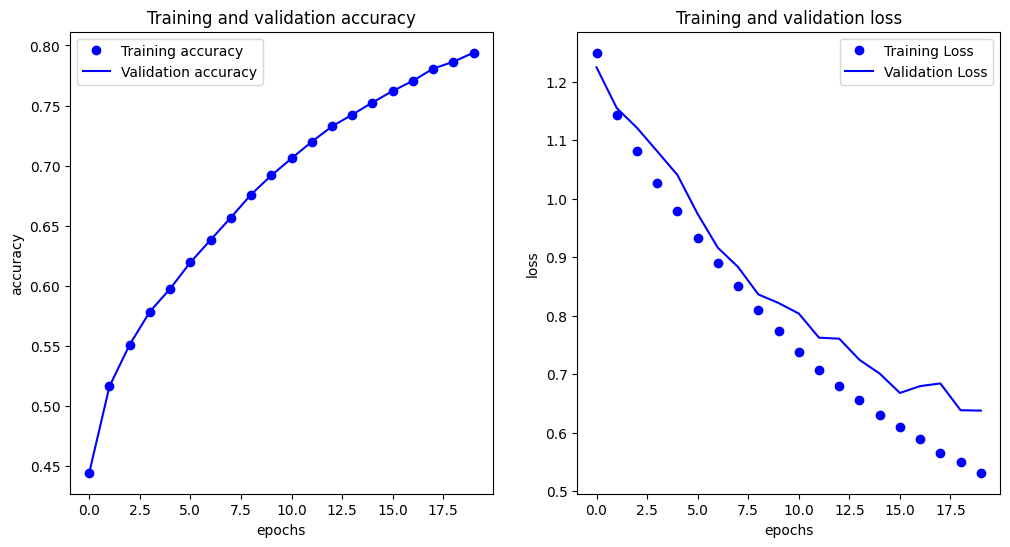

In [91]:
# Plot the accuracy and loss
plot_loss_acc(history_lstm)

In [92]:
loss, accuracy = model_lstm.evaluate(test_dataset_final)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6378 - sparse_categorical_accuracy: 0.7740 
Loss:  0.6377500295639038
Accuracy:  0.7739999890327454


In [93]:
model_lstm.predict(test_dataset_final)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


array([[9.2993200e-02, 2.0570213e-02, 5.8995301e-01, 2.9648352e-01],
       [6.1517853e-06, 3.4297605e-05, 9.9994242e-01, 1.7077653e-05],
       [9.1457856e-01, 6.6706510e-03, 7.3792264e-02, 4.9585053e-03],
       ...,
       [3.9021358e-02, 5.4046708e-01, 4.1259563e-01, 7.9158777e-03],
       [2.0839453e-02, 7.6130116e-01, 2.0668980e-01, 1.1169526e-02],
       [3.3938358e-07, 3.9973092e-06, 9.9999380e-01, 1.8633249e-06]],
      dtype=float32)

## Export the model

to make your model capable of processing raw strings (for example, to simplify deploying it), you can include the `TextVectorization` layer inside your model. To do so, you can create a new model using the weights you just trained.

In [108]:
export_model = tf.keras.Sequential([
  vectorize_layer,
  model_lstm,
  tf.keras.layers.Activation('softmax')
])

export_model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), optimizer="adam", metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

# Build a (raw_text, label) dataset from the validation dataframe and encoded labels
# Do NOT vectorize here because `export_model` already includes `vectorize_layer` as its
test_ds_for_eval = tf.data.Dataset.from_tensor_slices((df2[3].to_numpy(), label_sequences2)).batch(NUM_BATCHES)

metrics = export_model.evaluate(test_ds_for_eval, return_dict=True)
print(metrics)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0118 - sparse_categorical_accuracy: 0.7740 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0118 - sparse_categorical_accuracy: 0.7740 
{'loss': 1.0117793083190918, 'sparse_categorical_accuracy': 0.7739999890327454}
{'loss': 1.0117793083190918, 'sparse_categorical_accuracy': 0.7739999890327454}


To get predictions for new examples, you can simply call `export_model.predict()`.

In [111]:
examples = tf.constant([
  "The movie was great!",
  "The movie was okay.",
  "The movie was terrible",
  "The movie was excellent"
])

export_model.predict(examples)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


array([[0.19251345, 0.4209919 , 0.19960915, 0.18688548],
       [0.2505846 , 0.25413525, 0.27963322, 0.21564692],
       [0.19943859, 0.287036  , 0.30943945, 0.2040859 ],
       [0.19506136, 0.3893967 , 0.21701989, 0.19852206]], dtype=float32)